# Glutamate sequence QC

Inspect facilitation/adaptation metrics derived from repeated image sequences.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%matplotlib notebook

In [3]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [225]:
analysis_dir = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-28_810196\analysis') / 'derived' / 'glutamate' /'glutamate_analysis'
sequence_path = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-28_810196\analysis') / 'derived' / 'glutamate' / 'glutamate_sequence_df.npz'
sequence_per_image = pd.read_parquet(analysis_dir / 'sequence_per_image_table.parquet')
sequence_summary = pd.read_parquet(analysis_dir / 'sequence_summary_table.parquet')
sequence_summary

,session_id,subject_id,dmd,synapse_id,n_images_with_sequences,median_seq_slope,median_adaptation_index,median_r0,median_rlast,median_rterminal,median_terminal_minus_last,median_early_minus_late,seq_p,sequence_class,seq_q
0,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0000,7,-143.787215,0.952179,3866.683767,38.526398,3613.901450,3719.924535,2190.824967,0.031250,stable,0.185547
1,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0001,7,-104.949799,1.000000,2363.125566,-178.938048,4329.998173,5946.571031,2562.663132,0.468750,stable,0.618490
2,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0003,7,-82.079058,-0.019996,2939.804676,3131.950642,3220.114762,288.844152,-318.996038,0.109375,stable,0.346354
3,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0004,7,-48.002957,1.000000,986.375999,-1667.974355,2639.585761,5627.224793,2839.398010,0.156250,stable,0.362043
4,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0005,7,-68.337780,-0.037733,879.281607,3511.380791,2438.718327,-1653.556439,-1953.267537,0.375000,stable,0.574597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0044,7,-22.304961,1.000000,1243.085273,-1212.131489,1538.653753,2750.785242,1577.967284,0.578125,stable,0.742188
91,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0045,7,-147.283507,0.435478,3435.951635,709.817780,2438.150123,3514.082418,2240.380198,0.015625,stable,0.123698
92,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0046,7,-108.592296,0.722517,2585.046707,713.156754,2411.143510,2404.889414,1613.928576,0.015625,stable,0.123698
93,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0047,7,-190.544519,1.000000,1764.773138,-4931.054566,1073.921018,5719.464473,5506.020071,0.015625,stable,0.123698


In [226]:
sequence_summary['sequence_class'].unique()

array(['stable'], dtype=object)

<IPython.core.display.Javascript object>


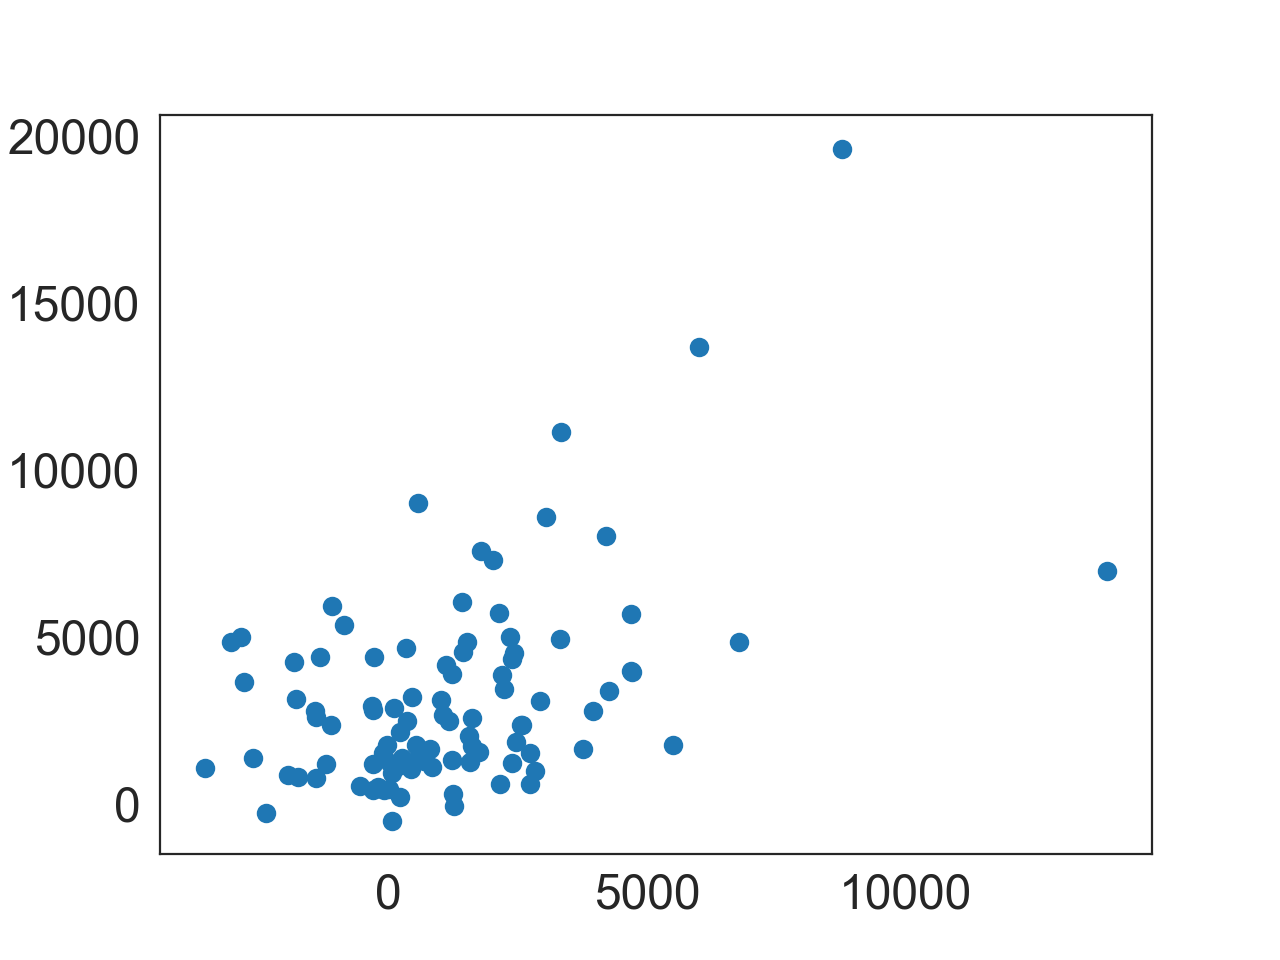

In [227]:
fig,ax=plt.subplots()

x = sequence_summary['median_early_minus_late']
y = sequence_summary['median_r0']

ax.scatter(x,y)

<IPython.core.display.Javascript object>


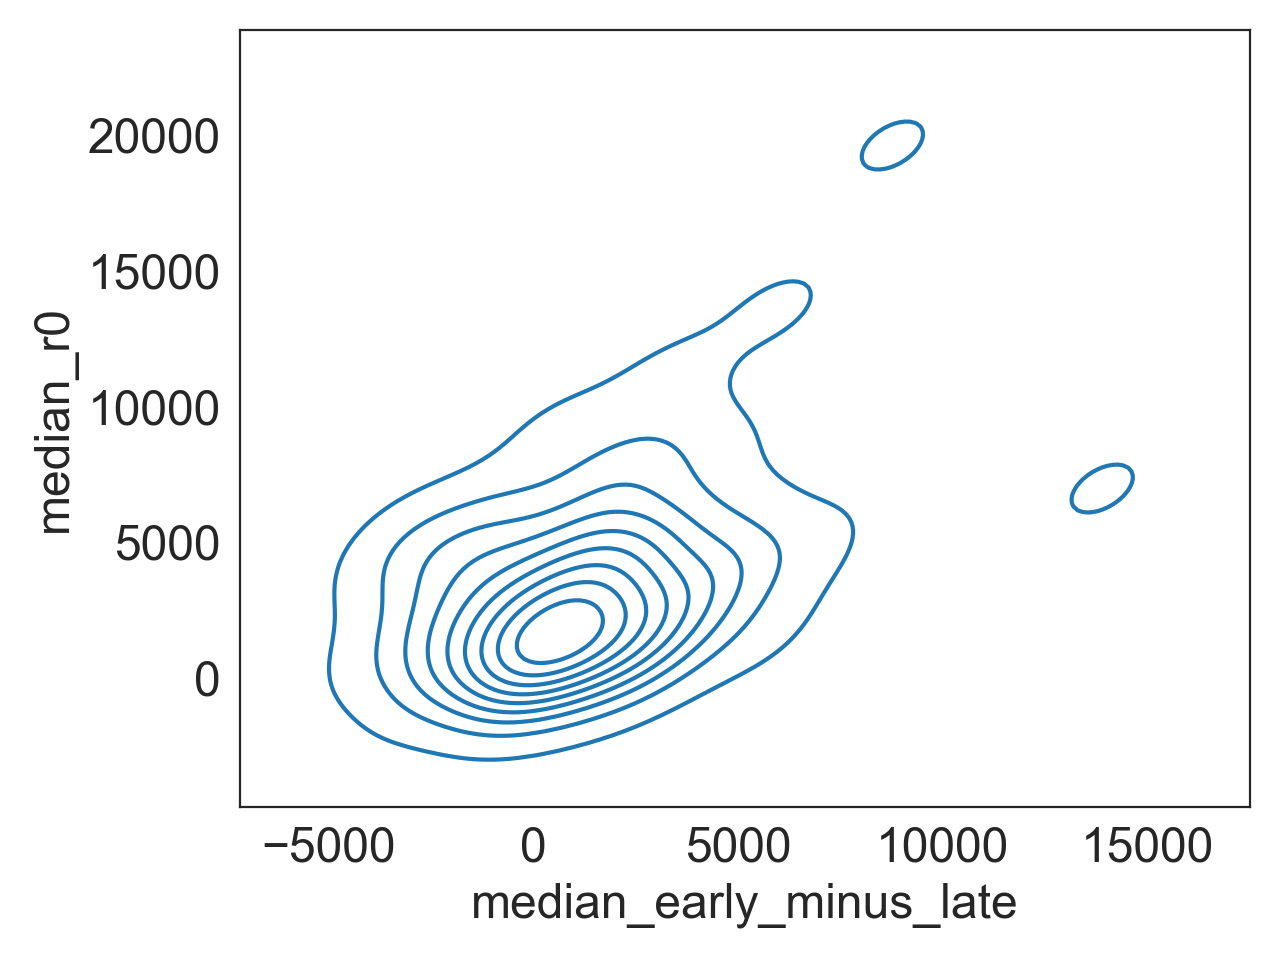

In [228]:
fig,ax=plt.subplots()

x =  'median_early_minus_late'
y = 'median_r0'

sns.kdeplot(data=sequence_summary,x=x,y=y)
fig.tight_layout()

<IPython.core.display.Javascript object>


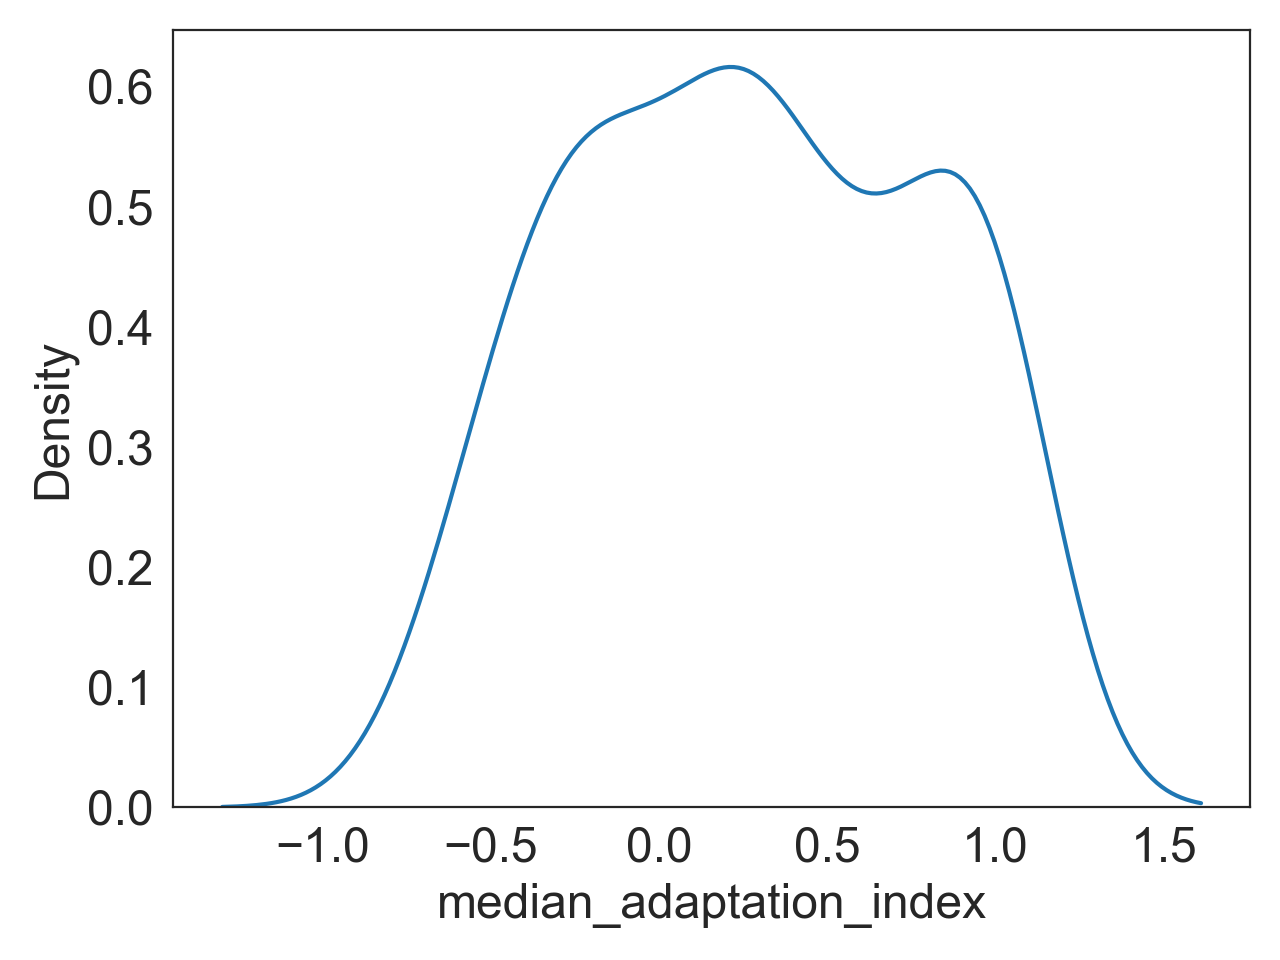

In [229]:
fig,ax=plt.subplots()

x =  'median_adaptation_index'
# y = 'median_r0'

sns.kdeplot(data=sequence_summary,x=x)
fig.tight_layout()

In [230]:
display(
    sequence_summary.groupby(['dmd', 'sequence_class']).size().rename('n').reset_index()
)

,dmd,sequence_class,n
0,DMD1,stable,51
1,DMD2,stable,44


<IPython.core.display.Javascript object>


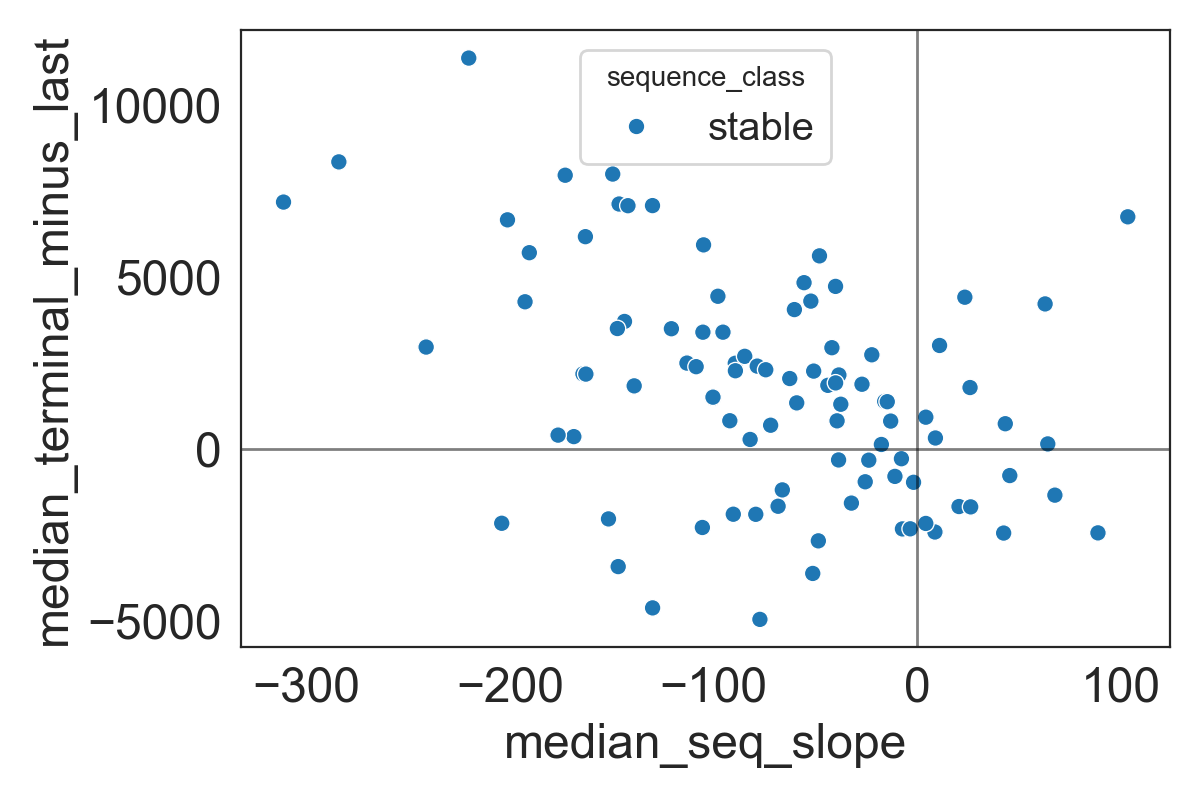

In [231]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=sequence_summary, x='median_seq_slope', y='median_terminal_minus_last', hue='sequence_class')
plt.axvline(0, color='k', lw=1, alpha=0.5)
plt.axhline(0, color='k', lw=1, alpha=0.5)
plt.tight_layout()

In [232]:
im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2']

In [233]:
seq_df = np.load(sequence_path,allow_pickle=True)['data'][0]

In [234]:
sequence_summary.sort_values("median_seq_slope")

,session_id,subject_id,dmd,synapse_id,n_images_with_sequences,median_seq_slope,median_adaptation_index,median_r0,median_rlast,median_rterminal,median_terminal_minus_last,median_early_minus_late,seq_p,sequence_class,seq_q
55,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0004,7,-311.292888,1.000000,6983.152078,-413.350121,6777.835569,7191.185690,13892.572622,0.296875,stable,0.494792
18,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0033,7,-284.119145,1.000000,4860.862600,-3835.001500,4372.523462,8359.954574,6785.906374,0.015625,stable,0.123698
60,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0011,7,-241.227526,0.655164,3976.279244,828.416056,3005.304630,2975.498591,4689.088924,0.015625,stable,0.123698
34,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0060,7,-220.302377,0.455102,19612.404806,8348.540485,19727.188369,11378.647884,8767.810254,0.218750,stable,0.451766
59,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0010,7,-204.101630,0.476207,4832.638705,12998.245075,10425.017853,-2148.532003,1507.793924,0.156250,stable,0.362043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0019,7,62.830997,0.004353,4847.470774,2505.519263,3793.122551,4229.711688,-3057.051847,1.000000,stable,1.000000
50,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0081,7,64.142357,-0.601660,-267.658760,170.608330,329.517193,158.908863,-2372.334147,0.015625,stable,0.123698
77,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0030,7,67.632550,0.448202,1642.396244,625.790229,1419.041840,-1330.667984,3757.067940,0.375000,stable,0.574597
40,810196_2025-07-28_19-59-05,810196,DMD1,DMD1_syn0069,7,88.796050,-0.260917,1086.713715,2232.367779,1345.567779,-2427.475040,-3550.174124,0.078125,stable,0.274884


<IPython.core.display.Javascript object>


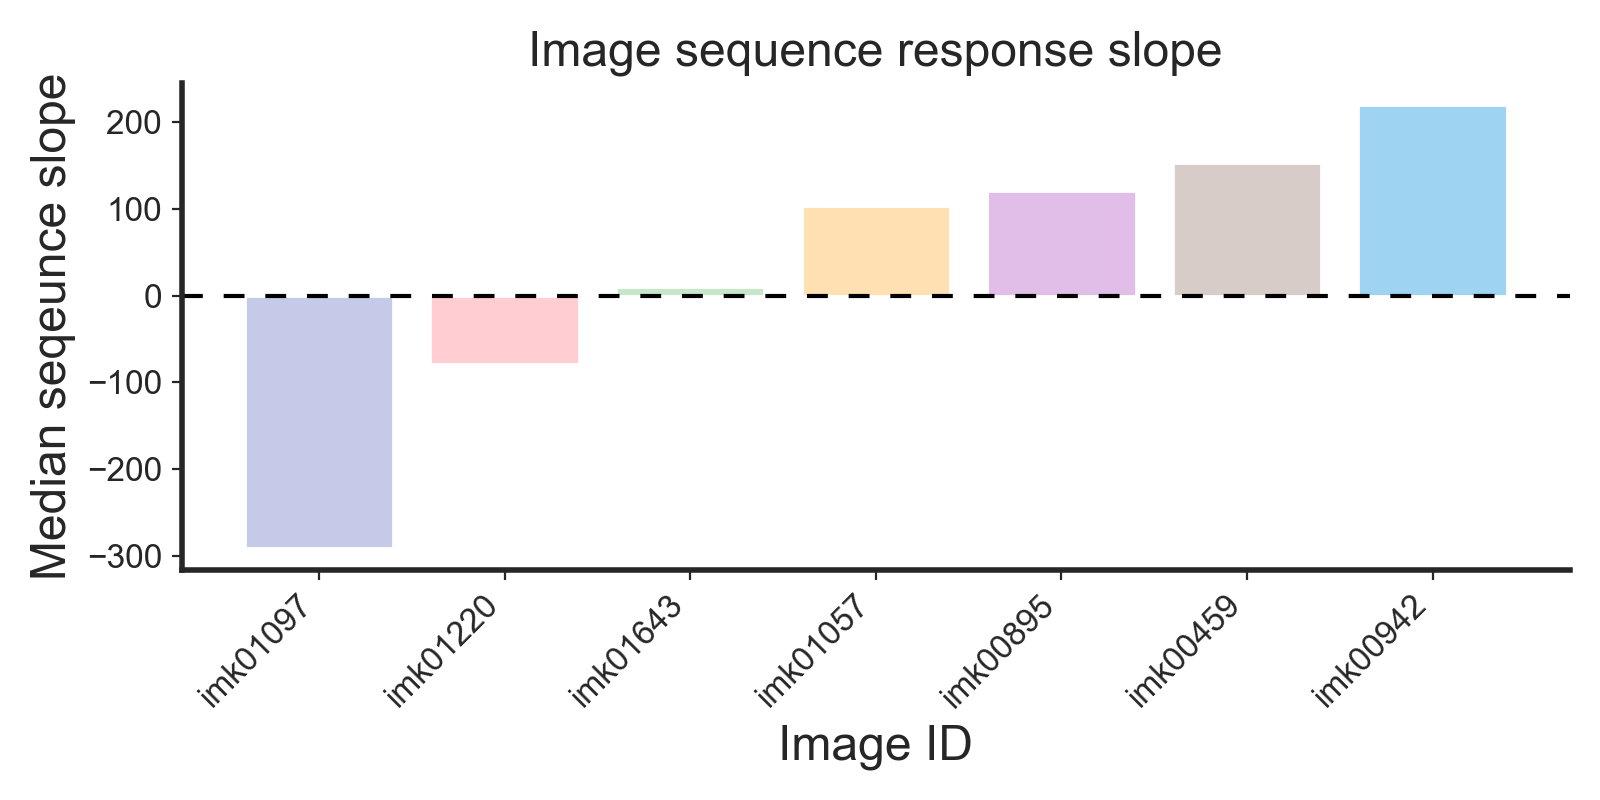

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_positions,n_sequences,r0,rlast,...,late_mean,early_minus_late,adaptation_index,sequence_slope,sequence_slope_norm,image_selectivity_score,ranking_score,image_rank_within_synapse,rank_basis,is_preferred_ranked_image
451,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0015,stimuli\images_A\imk01097.tiff,imk01097,13,39,691.377580,2106.012528,...,-406.753709,3000.315957,-0.505698,-290.456964,-0.420113,-6808.219554,-6808.219554,6,selectivity_score,False
448,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0015,stimuli\images_A\imk01220.tiff,imk01220,21,39,4965.703320,-12672.359910,...,-9597.618178,15884.603526,1.000000,-79.081567,-0.015926,-623.308170,-623.308170,3,selectivity_score,False
450,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0015,stimuli\images_A\imk01643.tiff,imk01643,17,39,4391.696108,-3610.328190,...,696.600189,2113.535256,1.000000,9.900020,0.002254,-4761.513125,-4761.513125,4,selectivity_score,False
452,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0015,stimuli\images_A\imk01057.tiff,imk01057,18,37,-152.037449,7434.018867,...,682.105150,-284.639067,-1.000000,103.447540,0.680408,-6728.756093,-6728.756093,5,selectivity_score,False
454,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0015,stimuli\images_A\imk00895.tiff,imk00895,18,38,1904.422122,1834.417898,...,6129.703734,-6280.909656,0.018724,120.224953,0.063129,-9957.744145,-9957.744145,7,selectivity_score,False
449,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0015,stimuli\images_A\imk00459.tiff,imk00459,18,38,21110.235016,37729.760147,...,26444.333929,-10198.718915,-0.282453,152.525162,0.007225,8623.601259,8623.601259,2,selectivity_score,False
453,810196_2025-07-28_19-59-05,810196,DMD2,DMD2_syn0015,stimuli\images_A\imk00942.tiff,imk00942,17,38,26448.603114,84458.634727,...,65475.710768,-39158.859997,-0.523050,220.219084,0.008326,20255.939827,20255.939827,1,selectivity_score,True


In [235]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

example_dmd = 'DMD2'
example_synapse_id = f'{example_dmd}_syn0015'

sub = (
    sequence_per_image[
        (sequence_per_image["dmd"] == example_dmd) &
        (sequence_per_image["synapse_id"] == example_synapse_id)
    ]
    .sort_values("sequence_slope")
    .copy()
)

stim_order = sub['stimulus_label'].tolist()
palette = [im_colors[i % len(im_colors)] for i in range(len(sub))]

# pick the right column name here
# yerr = sub['sem_seq_slope'].to_numpy()   # or sub['std_seq_slope']

ax.bar(
    np.arange(len(sub)),
    sub['sequence_slope'].to_numpy(),
    color=palette,
#     edgecolor='k',
    linewidth=1,
#     yerr=yerr,
    capsize=4,
    error_kw={'linewidth': 1.5, 'color': 'k'}
)

ax.set_xticks(np.arange(len(sub)))
ax.set_xticklabels(stim_order, rotation=45, ha='right')

ax.set_xlabel('Image ID')
ax.set_ylabel('Median seqeunce slope')

ax.axhline(0,color='k',dashes=[5,5])

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
ax.set_title('Image sequence response slope')
plt.tight_layout()
sub.head(20)

In [236]:
keys = list(seq_df['DMD1']['image_identity'].keys())
print(keys)

['stimuli\\images_A\\imk01220.tiff', 'stimuli\\images_A\\imk00459.tiff', 'stimuli\\images_A\\imk01643.tiff', 'stimuli\\images_A\\imk01097.tiff', 'stimuli\\images_A\\imk01057.tiff', 'stimuli\\images_A\\imk00942.tiff', 'stimuli\\images_A\\imk00895.tiff']


<IPython.core.display.Javascript object>


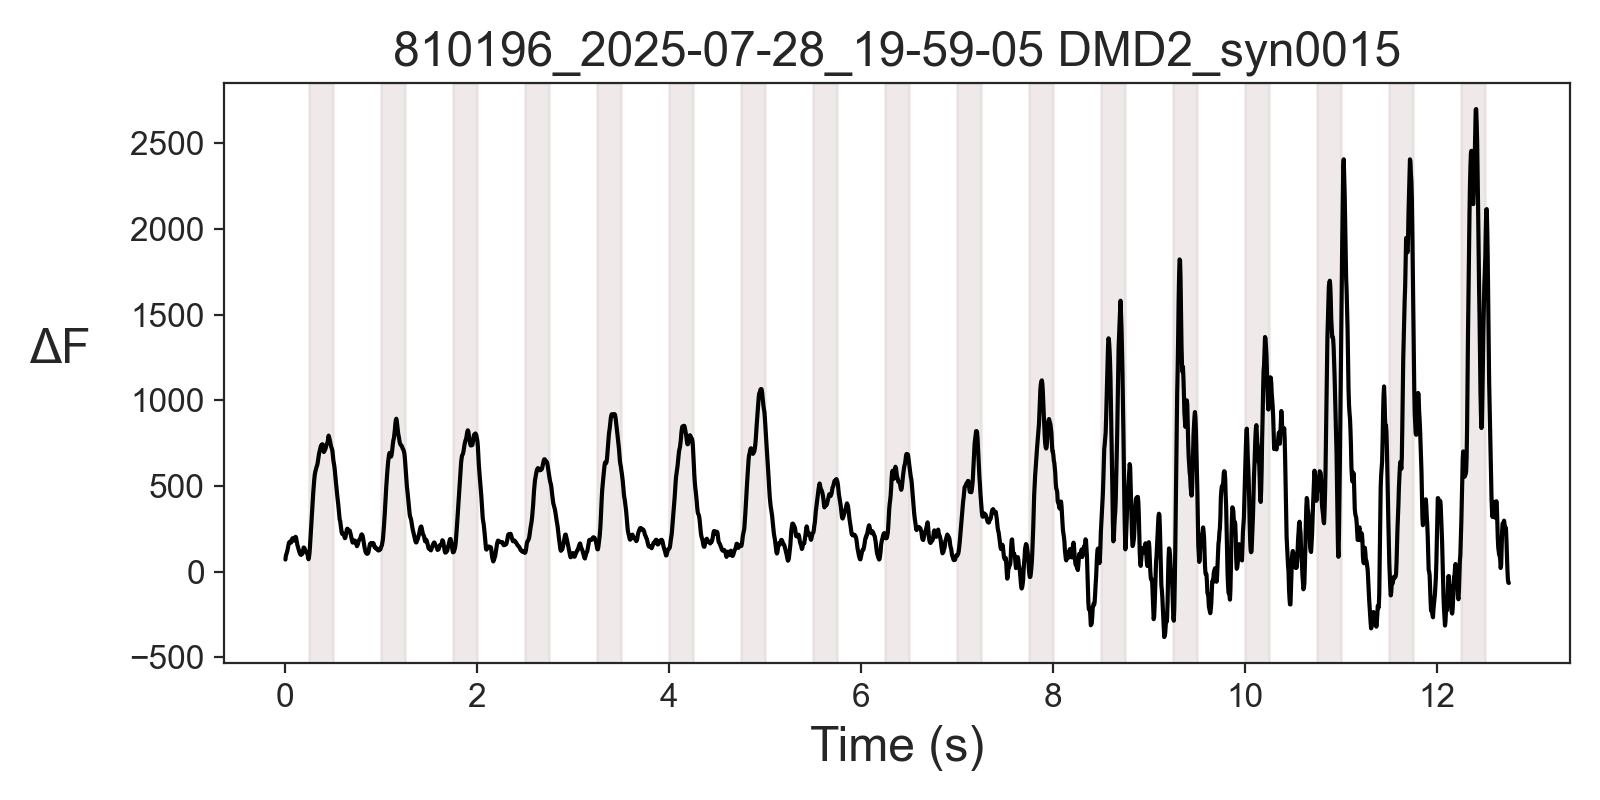

In [246]:
dmd = 2
syn = 15
im = -2

mean_im1_resps = seq_df[f'DMD{dmd}']['image_identity'][keys[im]]['repeated']['mean'].transpose(1,0,2)[syn][:]

shape = mean_im1_resps.shape
concat_traces = mean_im1_resps.reshape(shape[0]*shape[1])

fig,ax=plt.subplots(figsize=(8,4))
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
mean = concat_traces
mean_rolling = pd.DataFrame(concat_traces).rolling(10,min_periods=1).mean()
time = np.linspace(0,len(mean)/200,len(mean))
ax.plot(time,mean_rolling,color='k')

ax.set_xlabel('Time (s)')
ax.set_ylabel('\u0394F',rotation=0,labelpad=25)
fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

n_flashes = shape[0]  # change as needed

for i in range(n_flashes):
    start = flash_start + i * cycle_dur
    end = start + flash_dur
    ax.axvspan(start, end, alpha=0.4,color=im_colors[im])
ax.set_title(f'{sub["session_id"].unique()[0]} {sub["synapse_id"].unique()[0]}')
fig.tight_layout()

In [242]:
mean_im1_resps.shape

(8, 150)